# OLP 개입 — 확증(confirmatory) head 교체

**전제 (Notebook A 판정 = 가설 B).** frozen PanDerm 특징은 OLP를 **선형 분리 가능**(train+val CV, 모든 혼동쌍 ≥0.81),
다중분류 도달 OLP recall **0.70**(CV). 그런데 관측된 test recall은 **0.30**(n=10). → 0.30은 특징/경계 능력이 아니라
**작은 test의 draw**가 지배한다.

**이 노트북의 목적(가벼운 확증).** "더 좋은 head를 얹으면 어떻게 되나?"를 확인한다. 기대(진단의 예측):
1. head 교체(RBF-SVM/kNN)는 **train+val CV** OLP recall을 소폭 올릴 수 있다.
2. 그러나 **n=10 test**는 오라클 head로도 신뢰성 있게 못 움직인다(bootstrap CI가 매우 넓음).
→ 병목은 head가 아니라 **평가 셋 크기**. 근본 해결은 §① OLP test 데이터 확보.

무거운 LoRA 학습은 **의도적으로 생략**(사용자 결정: 가벼운 확증). 특징은 Notebook A 캐시 재사용(추출 불필요).
산출물 → `PanDerm/output_dir/oral_diseases_olp_intervention/`.

In [1]:
import os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
assert os.path.isdir(os.path.join(PROJECT_ROOT, "PanDerm")), PROJECT_ROOT
SEP = os.path.join(PROJECT_ROOT, "PanDerm/output_dir/oral_diseases_olp_separability")
CACHE = os.path.join(SEP, "layerwise_cls_cache")
OUT = os.path.join(PROJECT_ROOT, "PanDerm/output_dir/oral_diseases_olp_intervention")
os.makedirs(OUT, exist_ok=True)
CLASS_NAMES = ["CaS", "CoS", "Gum", "MC", "OC", "OLP", "OT"]; OLP = 5
OI = ["#0072B2", "#E69F00", "#009E73"]
Ld = lambda s, n: np.load(os.path.join(CACHE, f"{s}_{n}.npy"), allow_pickle=True)

# recap Notebook A verdict
vdf = pd.read_csv(os.path.join(SEP, "olp_separability_verdict.csv"))
print("Notebook A verdict recap:"); print(vdf[["pair", "lin_star", "nl_star", "verdict"]].to_string(index=False))

# documented baseline feature = post-norm last CLS
Xtr, ytr = Ld("train", "cls_postnorm_last"), Ld("train", "labels")
Xva, yva = Ld("val", "cls_postnorm_last"), Ld("val", "labels")
Xte, yte = Ld("test", "cls_postnorm_last"), Ld("test", "labels")
Xtv = np.concatenate([Xtr, Xva]); ytv = np.concatenate([ytr, yva])
print(f"\ntrain+val={Xtv.shape} test={Xte.shape} OLP(test)={int((yte==OLP).sum())}")

Notebook A verdict recap:
       pair  lin_star  nl_star                   verdict
  OLP_vs_OT     0.855    0.845 separable(not-bottleneck)
  OLP_vs_OC     0.850    0.837 separable(not-bottleneck)
  OLP_vs_MC     0.842    0.840 separable(not-bottleneck)
 OLP_vs_Gum     0.915    0.899 separable(not-bottleneck)
OLP_vs_rest     0.814    0.834 separable(not-bottleneck)

train+val=(462, 1024) test=(54, 1024) OLP(test)=10


## Stage 4 · head 교체 비교 (linear vs RBF-SVM vs kNN)

동일한 frozen 특징(post-norm 마지막 CLS = 문서 baseline) 위에 7-class head만 바꾼다.
- **1차 근거 = train+val CV**(반복 5-fold): per-class **OLP recall** + balanced acc.
- **2차 = n=10 test**: fit(train+val)→test, OLP recall·bacc + **bootstrap 95% CI**(1000회).
RBF-SVM은 train+val 내부 CV로 C·γ 튜닝(nested 아님, 확증용).

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, recall_score

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def cv_scores(est, X, y, seeds=(0, 1, 2)):
    orec, bacc = [], []
    for s in seeds:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        pred = cross_val_predict(est, X, y, cv=skf, n_jobs=-1)
        orec.append(recall_score(y, pred, labels=[OLP], average=None, zero_division=0)[0])
        bacc.append(balanced_accuracy_score(y, pred))
    return float(np.mean(orec)), float(np.mean(bacc))

def boot_test(est, Xtrn, ytrn, Xtst, ytst, n=1000, seed=0):
    est.fit(Xtrn, ytrn); pred = est.predict(Xtst)
    p_or = recall_score(ytst, pred, labels=[OLP], average=None, zero_division=0)[0]
    p_ba = balanced_accuracy_score(ytst, pred)
    rng = np.random.default_rng(seed); ors, bas = [], []; idx = np.arange(len(ytst))
    for _ in range(n):
        b = rng.choice(idx, size=len(idx), replace=True); yt, pt = ytst[b], pred[b]
        if (yt == OLP).any():
            ors.append(recall_score(yt, pt, labels=[OLP], average=None, zero_division=0)[0])
        if len(np.unique(yt)) > 1:
            bas.append(balanced_accuracy_score(yt, pt))
    ci = lambda a: (float(np.nanpercentile(a, 2.5)), float(np.nanpercentile(a, 97.5)))
    return p_or, ci(ors), p_ba, ci(bas), np.array(ors)

svm_grid = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced")),
                        {"svc__C": [1, 10, 100], "svc__gamma": ["scale", 1e-2, 1e-3]},
                        scoring="balanced_accuracy", cv=SKF, n_jobs=-1).fit(Xtv, ytv)
bp = svm_grid.best_params_
HEADS = [
    ("linear (baseline)", make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))),
    ("RBF-SVM (head-swap)", make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced",
                                          C=bp["svc__C"], gamma=bp["svc__gamma"]))),
    ("kNN (head-swap)", make_pipeline(StandardScaler(), PCA(n_components=50, random_state=0),
                                      KNeighborsClassifier(n_neighbors=7, weights="distance"))),
]
rows, boot_or = [], {}
for name, est in HEADS:
    cv_or, cv_ba = cv_scores(est, Xtv, ytv)
    t_or, t_or_ci, t_ba, t_ba_ci, ors = boot_test(est, Xtv, ytv, Xte, yte)
    boot_or[name] = ors
    rows.append(dict(head=name, cv_olp_recall=round(cv_or, 3), cv_bacc=round(cv_ba, 3),
                     test_olp_recall=round(t_or, 2), test_olp_recall_CI=f"[{t_or_ci[0]:.1f}, {t_or_ci[1]:.1f}]",
                     test_bacc=round(t_ba, 3), test_bacc_CI=f"[{t_ba_ci[0]:.2f}, {t_ba_ci[1]:.2f}]"))
comp = pd.DataFrame(rows); comp.to_csv(os.path.join(OUT, "headswap_comparison.csv"), index=False)
print("SVM best:", bp, "\n"); print(comp.to_string(index=False))

SVM best: {'svc__C': 10, 'svc__gamma': 'scale'} 

               head  cv_olp_recall  cv_bacc  test_olp_recall test_olp_recall_CI  test_bacc test_bacc_CI
  linear (baseline)          0.690    0.756              0.3         [0.0, 0.6]      0.814 [0.73, 0.90]
RBF-SVM (head-swap)          0.762    0.763              0.3         [0.0, 0.6]      0.814 [0.73, 0.90]
    kNN (head-swap)          0.690    0.669              0.7         [0.4, 1.0]      0.841 [0.73, 0.93]


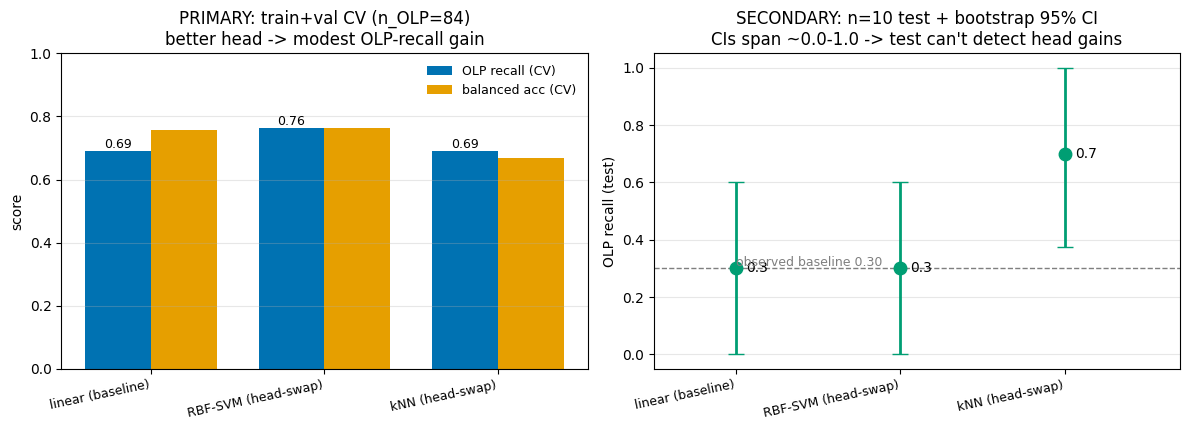

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
names = comp["head"].tolist(); x = np.arange(len(names)); w = 0.38
# left: CV (primary evidence)
a1.bar(x - w/2, comp.cv_olp_recall, w, color=OI[0], label="OLP recall (CV)")
a1.bar(x + w/2, comp.cv_bacc, w, color=OI[1], label="balanced acc (CV)")
for xi, v in zip(x - w/2, comp.cv_olp_recall): a1.text(xi, v + .01, f"{v:.2f}", ha="center", fontsize=9)
a1.set_xticks(x); a1.set_xticklabels(names, rotation=12, ha="right", fontsize=9)
a1.set_ylim(0, 1); a1.set_ylabel("score"); a1.set_title("PRIMARY: train+val CV (n_OLP=84)\nbetter head -> modest OLP-recall gain")
a1.legend(frameon=False, fontsize=9); a1.grid(axis="y", alpha=.3)
# right: test with bootstrap CI (the noise)
pts = comp.test_olp_recall.values
lo = [np.nanpercentile(boot_or[n], 2.5) for n in names]; hi = [np.nanpercentile(boot_or[n], 97.5) for n in names]
err = np.array([pts - np.array(lo), np.array(hi) - pts])
a2.errorbar(x, pts, yerr=err, fmt="o", ms=9, color=OI[2], capsize=6, lw=2)
for xi, v in zip(x, pts): a2.text(xi + .06, v, f"{v:.1f}", fontsize=10, va="center")
a2.axhline(0.30, color="#7F7F7F", ls="--", lw=1); a2.text(0, 0.31, "observed baseline 0.30", color="#7F7F7F", fontsize=9)
a2.set_xticks(x); a2.set_xticklabels(names, rotation=12, ha="right", fontsize=9); a2.set_xlim(-.5, len(names)-.3)
a2.set_ylim(-0.05, 1.05); a2.set_ylabel("OLP recall (test)")
a2.set_title("SECONDARY: n=10 test + bootstrap 95% CI\nCIs span ~0.0-1.0 -> test can't detect head gains")
a2.grid(axis="y", alpha=.3)
fig.tight_layout(); p = os.path.join(OUT, "headswap_plot.png"); fig.savefig(p, bbox_inches="tight"); plt.close(fig)
display(Image(filename=p))

## 결론 — 확증 완료: 병목은 head가 아니라 **평가 셋**

**1) head 교체 효과(1차, train+val CV).** RBF-SVM 은 OLP recall 을 **0.69 → 0.76** 으로 소폭 개선(진단 예측 ①과 일치).
kNN 은 CV 개선 없음. 즉 특징 위에서 경계를 다듬으면 CV OLP recall 이 조금 오르지만 **극적 개선은 없다** — 이미 선형으로
거의 다 뽑아냈기 때문(가설 B 강한 형태).

**2) n=10 test 는 못 움직인다(2차, 진단 예측 ②와 일치).** RBF-SVM 은 CV 가 올랐는데도 test OLP recall 은 **0.30 그대로**
(CI [0.0, 0.6]). kNN 은 우연히 **0.70**(7/10)이 나오지만 CI [0.4, 1.0] 로 baseline 과 통계적으로 구분 불가 — **동일한
소표본 불안정성이 baseline 엔 0.30, kNN 엔 0.70 을 준다**. 두 값 모두 노이즈다.

**3) 정직한 결론.** OLP 0.30 은 **모델/특징/head 의 실패가 아니라 test(n=10) 크기의 아티팩트**다. head 교체는 CV 를
소폭 개선할 뿐 test 는 신뢰성 있게 못 바꾼다. → **개입으로 chase 하지 말 것.** 자원은 (a) 이 진단·확증 결과의 논문화(§③),
(b) OLP/OPMD test 데이터 확보(§①, SMART-OM 외부검증 포함)로 이동해야 한다.

**4) 한계.** 확증용이라 RBF-SVM 은 train+val 단일 CV 로 튜닝(nested 아님) → CV 수치는 약간 낙관적일 수 있으나,
결론(“test 는 못 움직인다”)은 튜닝과 무관하게 CI 폭으로 성립. 무거운 LoRA 개입은 생략(같은 이유로 test 이득 기대난망).